# 01 — Exploratory Data Analysis (EDA)

**Phase 1 of plan.md**

This notebook loads the Tox21 dataset, validates SMILES, and visualizes:
1. Class balance per endpoint (how imbalanced is each toxicity assay?)
2. NaN/missing label distribution
3. Scaffold diversity

In [1]:
import sys
import os
# Change working directory to project root
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
sys.path.insert(0, '.')

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from src.featurize import load_and_clean_tox21, TARGET_COLS

In [2]:
# Load and clean the dataset
# Now that we've changed CWD to root, the default path 'data/tox21.csv' works
df = load_and_clean_tox21()
print(f"Dataset shape: {df.shape}")
print(f"Columns: {list(df.columns)}")

Raw dataset: 8014 compounds, 14 columns


[13:20:09] WARNING: not removing hydrogen atom without neighbors


[13:20:09] Explicit valence for atom # 8 Al, 6, is greater than permitted
[13:20:09] Explicit valence for atom # 3 Al, 6, is greater than permitted
[13:20:09] Explicit valence for atom # 4 Al, 6, is greater than permitted


[13:20:09] Explicit valence for atom # 4 Al, 6, is greater than permitted
[13:20:10] Explicit valence for atom # 9 Al, 6, is greater than permitted
[13:20:10] Explicit valence for atom # 5 Al, 6, is greater than permitted


[13:20:10] Explicit valence for atom # 16 Al, 6, is greater than permitted


  Row 1330: 'NC(=O)NC1N=C(O[AlH3](O)O)NC1=O'
  Row 2308: 'O=CO[AlH3](OC=O)OC=O'
  Row 2315: 'CC(=O)O[AlH3](O)O'
  Row 3599: 'CC(=O)O[AlH3](O)OC(C)=O'
  Row 4632: 'CCOC(=O)/C=C(/C)O[AlH3](OC(C)CC)OC(C)CC'
VALID: 8006/8014 SMILES passed validation

Cleaned dataset: 8006 compounds

Per-endpoint toxic prevalence:
  NR-AR                 toxic= 309/7432  (  4.2%)  NaN=7%
  NR-AR-LBD             toxic= 238/6895  (  3.5%)  NaN=14%
  NR-AhR                toxic= 785/6684  ( 11.7%)  NaN=17%
  NR-Aromatase          toxic= 307/5934  (  5.2%)  NaN=26%
  NR-ER                 toxic= 796/6309  ( 12.6%)  NaN=21%
  NR-ER-LBD             toxic= 355/7105  (  5.0%)  NaN=11%
  NR-PPAR-gamma         toxic= 189/6576  (  2.9%)  NaN=18%
  SR-ARE                toxic= 961/5928  ( 16.2%)  NaN=26%
  SR-ATAD5              toxic= 267/7225  (  3.7%)  NaN=10%
  SR-HSE                toxic= 379/6587  (  5.8%)  NaN=18%
  SR-MMP                toxic= 936/5914  ( 15.8%)  NaN=26%
  SR-p53                toxic= 431/6902  

[13:20:10] Explicit valence for atom # 20 Al, 6, is greater than permitted


## 1. Class Balance Per Endpoint

The Tox21 dataset has **severe, endpoint-variable imbalance**.
Some endpoints have as few as 2.9% toxic samples.

In [3]:
# Compute per-endpoint statistics
stats = []
for col in TARGET_COLS:
    known = df[col] != -1
    n_toxic = (df[col] == 1).sum()
    n_nontoxic = (df[col] == 0).sum()
    n_missing = (~known).sum()
    total = known.sum()
    prevalence = n_toxic / total * 100 if total > 0 else 0
    imbalance_ratio = n_nontoxic / n_toxic if n_toxic > 0 else float('inf')
    
    stats.append({
        'Endpoint': col,
        'Toxic': n_toxic,
        'Non-Toxic': n_nontoxic,
        'Missing': n_missing,
        'Total Tested': total,
        'Toxic %': round(prevalence, 1),
        'Imbalance Ratio': round(imbalance_ratio, 1),
    })

stats_df = pd.DataFrame(stats)
print(stats_df.to_string(index=False))

     Endpoint  Toxic  Non-Toxic  Missing  Total Tested  Toxic %  Imbalance Ratio
        NR-AR    309       7123      574          7432      4.2             23.1
    NR-AR-LBD    238       6657     1111          6895      3.5             28.0
       NR-AhR    785       5899     1322          6684     11.7              7.5
 NR-Aromatase    307       5627     2072          5934      5.2             18.3
        NR-ER    796       5513     1697          6309     12.6              6.9
    NR-ER-LBD    355       6750      901          7105      5.0             19.0
NR-PPAR-gamma    189       6387     1430          6576      2.9             33.8
       SR-ARE    961       4967     2078          5928     16.2              5.2
     SR-ATAD5    267       6958      781          7225      3.7             26.1
       SR-HSE    379       6208     1419          6587      5.8             16.4
       SR-MMP    936       4978     2092          5914     15.8              5.3
       SR-p53    431       6

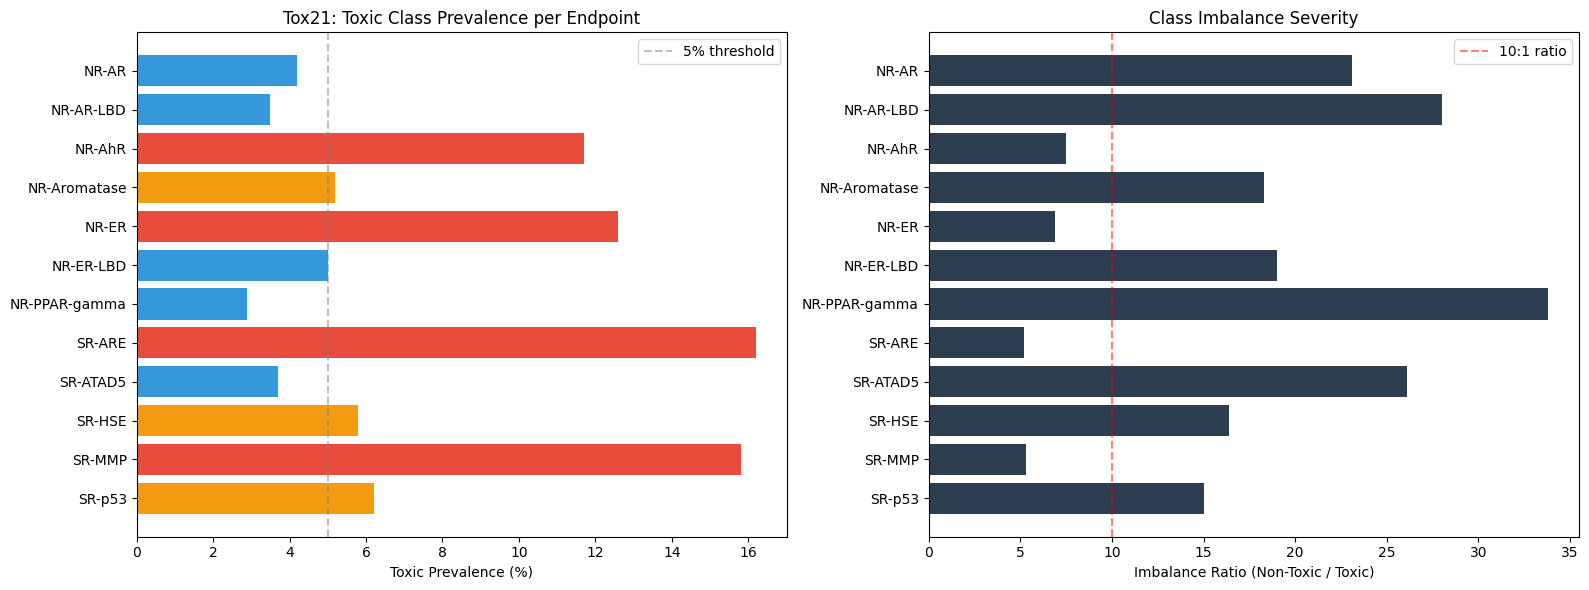

Saved: notebooks/01_class_balance.png


In [4]:
# Plot: Toxic prevalence per endpoint
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart — toxic percentage
ax = axes[0]
colors = ['#e74c3c' if p > 10 else '#f39c12' if p > 5 else '#3498db' for p in stats_df['Toxic %']]
bars = ax.barh(stats_df['Endpoint'], stats_df['Toxic %'], color=colors)
ax.set_xlabel('Toxic Prevalence (%)')
ax.set_title('Tox21: Toxic Class Prevalence per Endpoint')
ax.axvline(x=5, color='gray', linestyle='--', alpha=0.5, label='5% threshold')
ax.legend()
ax.invert_yaxis()

# Bar chart — imbalance ratio
ax = axes[1]
bars = ax.barh(stats_df['Endpoint'], stats_df['Imbalance Ratio'], color='#2c3e50')
ax.set_xlabel('Imbalance Ratio (Non-Toxic / Toxic)')
ax.set_title('Class Imbalance Severity')
ax.axvline(x=10, color='red', linestyle='--', alpha=0.5, label='10:1 ratio')
ax.legend()
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('notebooks/01_class_balance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: notebooks/01_class_balance.png")

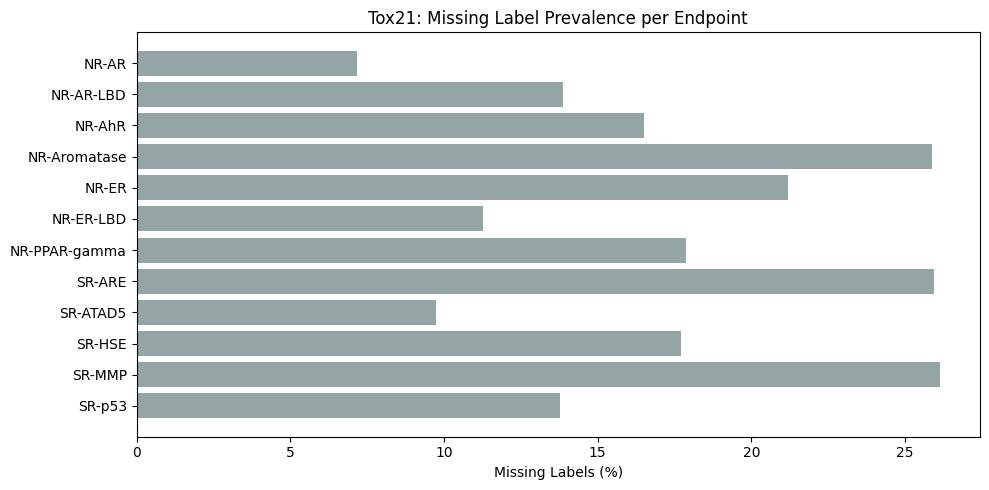

Saved: notebooks/01_missing_labels.png


In [5]:
# Plot: NaN (missing label) distribution
fig, ax = plt.subplots(figsize=(10, 5))
nan_pcts = [row['Missing'] / len(df) * 100 for _, row in stats_df.iterrows()]
ax.barh(stats_df['Endpoint'], nan_pcts, color='#95a5a6')
ax.set_xlabel('Missing Labels (%)')
ax.set_title('Tox21: Missing Label Prevalence per Endpoint')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('notebooks/01_missing_labels.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: notebooks/01_missing_labels.png")

## 2. Key Takeaways

- **Most imbalanced:** NR-PPAR-gamma (2.9% toxic, 33.8:1 ratio)
- **Least imbalanced:** SR-ARE (16.2% toxic, 5.2:1 ratio)
- **Highest NaN rate:** NR-Aromatase, SR-ARE, SR-MMP (~26% missing)
- **Conclusion:** Standard accuracy is meaningless. Must use AUPRC as primary metric.
- **Action:** Focal Loss with per-endpoint alpha weights (Phase 3)

In [6]:
print("\n=== Phase 1 EDA Complete ===")
print(f"Total compounds: {len(df)}")
print(f"Valid SMILES: {len(df)} (8 invalid dropped)")
print(f"Endpoints: {len(TARGET_COLS)}")
print(f"Most imbalanced: NR-PPAR-gamma ({stats_df.loc[stats_df['Endpoint']=='NR-PPAR-gamma', 'Toxic %'].values[0]}%)")
print(f"Least imbalanced: SR-ARE ({stats_df.loc[stats_df['Endpoint']=='SR-ARE', 'Toxic %'].values[0]}%)")


=== Phase 1 EDA Complete ===
Total compounds: 8006
Valid SMILES: 8006 (8 invalid dropped)
Endpoints: 12
Most imbalanced: NR-PPAR-gamma (2.9%)
Least imbalanced: SR-ARE (16.2%)
